In [50]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML

In [51]:
Node_coords= torch.tensor([[0,0],[2,0],[4,0],[1,1.732],[3,1.732]])
con = torch.tensor([[1,2],[2,3],[3,5],[4,5],[1,4],[4,2],[5,2]])-1
Areas = torch.tensor([1.0]*len(con))
lengths = torch.sqrt(((Node_coords[con[:, 1]] - Node_coords[con[:, 0]]) ** 2).sum(dim=1))
print(Areas)

tensor([1., 1., 1., 1., 1., 1., 1.])


In [52]:
Structural_volume = torch.sum(Areas * lengths, dim=0)
print(Structural_volume)

tensor(13.9998)


In [53]:
##### Put node 5 and node 4 in vertical movement
MV_nodes = torch.tensor([4,5]) - 1 
counters = torch.arange(0, 2.01, 0.01)
n = len(counters)

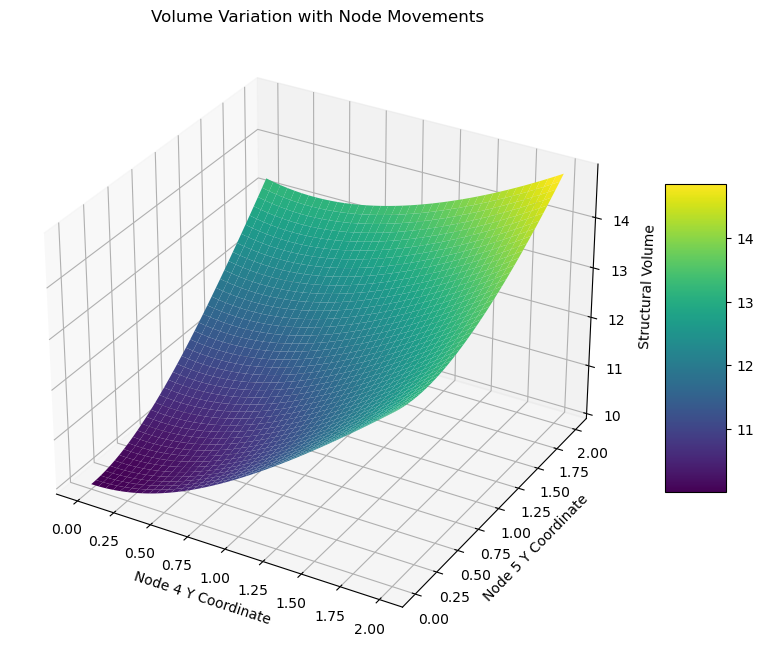

In [54]:
Volume_grid = torch.zeros((n, n))
for i, y4 in enumerate(counters):
    for j, y5 in enumerate(counters):
        modified_coords = Node_coords.clone()
        modified_coords[MV_nodes[0], 1] = y4  
        modified_coords[MV_nodes[1], 1] = y5  
        
        lengths = torch.sqrt(((modified_coords[con[:, 1]] - modified_coords[con[:, 0]]) ** 2).sum(dim=1))
        Volume_grid[i, j] = torch.sum(Areas * lengths)

X, Y = np.meshgrid(counters.numpy(), counters.numpy())
Z = Volume_grid.numpy()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

ax.set_xlabel('Node 4 Y Coordinate')
ax.set_ylabel('Node 5 Y Coordinate')
ax.set_zlabel('Structural Volume')
ax.set_title('Volume Variation with Node Movements')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

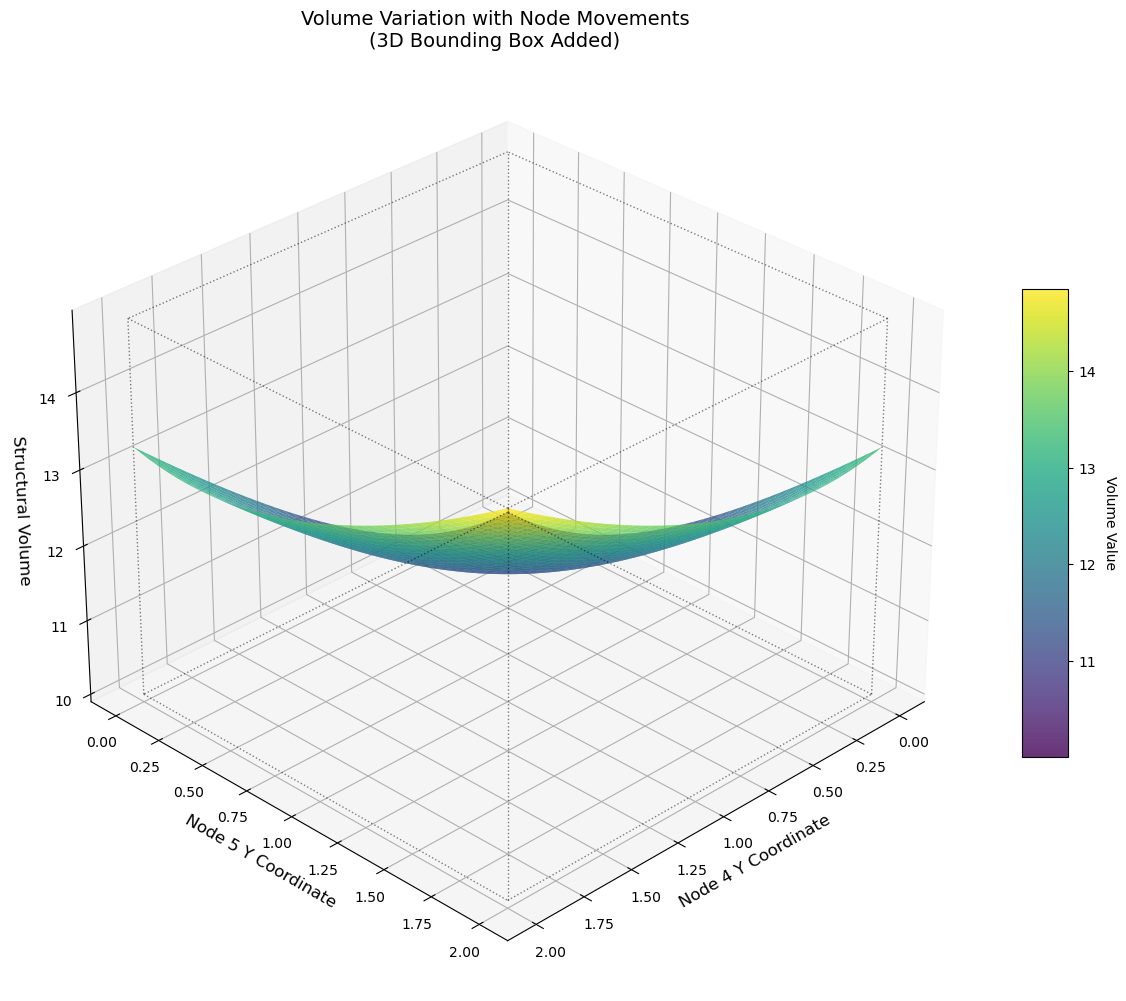

In [55]:
Volume_grid = torch.zeros((n, n))

for i, y4 in enumerate(counters):
    for j, y5 in enumerate(counters):
        modified_coords = Node_coords.clone()
        modified_coords[MV_nodes[0], 1] = y4
        modified_coords[MV_nodes[1], 1] = y5
        
        lengths = torch.sqrt(((modified_coords[con[:, 1]] - modified_coords[con[:, 0]]) ** 2).sum(dim=1))
        Volume_grid[i, j] = torch.sum(Areas * lengths)

X, Y = np.meshgrid(counters.numpy(), counters.numpy())
Z = Volume_grid.numpy()
z_min, z_max = Z.min(), Z.max()

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')


surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)


def make_cube_edges(xmin, xmax, ymin, ymax, zmin, zmax):
    edges = [
        [(xmin, ymin, zmin), (xmax, ymin, zmin)],
        [(xmax, ymin, zmin), (xmax, ymax, zmin)],
        [(xmax, ymax, zmin), (xmin, ymax, zmin)],
        [(xmin, ymax, zmin), (xmin, ymin, zmin)],
        [(xmin, ymin, zmax), (xmax, ymin, zmax)],
        [(xmax, ymin, zmax), (xmax, ymax, zmax)],
        [(xmax, ymax, zmax), (xmin, ymax, zmax)],
        [(xmin, ymax, zmax), (xmin, ymin, zmax)],
        [(xmin, ymin, zmin), (xmin, ymin, zmax)],
        [(xmax, ymin, zmin), (xmax, ymin, zmax)],
        [(xmax, ymax, zmin), (xmax, ymax, zmax)],
        [(xmin, ymax, zmin), (xmin, ymax, zmax)]
    ]
    return edges

edges = make_cube_edges(0, 2, 0, 2, z_min, z_max)
edge_collection = Line3DCollection(edges, colors='k', linewidths=1, linestyles=':', alpha=0.5)
ax.add_collection3d(edge_collection)

ax.set_xlabel('Node 4 Y Coordinate', fontsize=12)
ax.set_ylabel('Node 5 Y Coordinate', fontsize=12)
ax.set_zlabel('Structural Volume', fontsize=12)
ax.set_title('Volume Variation with Node Movements\n(3D Bounding Box Added)', fontsize=14)

cbar = fig.colorbar(surf, shrink=0.5, aspect=10)
cbar.set_label('Volume Value', rotation=270, labelpad=15)

ax.view_init(elev=30, azim=45)

plt.tight_layout()
plt.show()

In [56]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML


counters = torch.linspace(0, 2, 30)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

def update(frame):
    ax.clear()
    
    modified_coords = Node_coords.clone()
    y_val = counters[frame]
    modified_coords[MV_nodes[0], 1] = y_val          
    modified_coords[MV_nodes[1], 1] = 2.0 - y_val    
    
    lengths = torch.sqrt(((modified_coords[con[:,1]] - modified_coords[con[:,0]])**2).sum(dim=1))
    volume = torch.sum(lengths * 1.0).item()  # 假设所有Area=1.0
    
    ax.scatter(modified_coords[:,0], modified_coords[:,1], np.zeros(5),
               c=['r','r','r','g','g'], s=80, depthshade=True)
    
    for (i,j) in con:
        ax.plot([modified_coords[i,0], modified_coords[j,0]],
                [modified_coords[i,1], modified_coords[j,1]],
                [0, 0], 'b-', linewidth=2)
    
    ax.scatter(modified_coords[:,0], modified_coords[:,1], 
               np.full(5, volume/3), 
               c='purple', alpha=0.2, s=50)
    
    ax.set_xlim(-1, 5)
    ax.set_ylim(-1, 3)
    ax.set_zlim(0, 5)
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_zlabel('Volume (scaled)')
    ax.set_title(f'Frame {frame+1}/{len(counters)}\nVolume: {volume:.2f}')
    ax.view_init(elev=30, azim=-60)  
    
    return ax

ani = FuncAnimation(fig, update, frames=len(counters), interval=150, blit=False)

ani.save('structure_animation.gif', 
         writer=PillowWriter(fps=8), 
         dpi=100)

plt.close()
HTML(ani.to_jshtml())